In [38]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

# Show all columns instead of truncating with "..." when printing wide DataFrames
pd.set_option("display.max_columns", None)

# Widen the console output so rows don't wrap awkwardly across multiple lines
pd.set_option("display.width", 120)


## 1. Initial Inspection & Label Quality

This group only establishes what was actually received: can the file be loaded, what does a raw sample look like, and can the target label be trusted enough to build the rest of the notebook on it. Nothing hereinspects individual columns for quality issues yet that starts in Group 2.


### Auditing Label Quality

This is what we want to do here.
> Before analyzing any feature, we want to sample and manually verify a random subset of labels (roughly 30-100 rows) against raw source evidence (were they entered by humans (survey, manual tagging), collected automatically (a sensor, a system log, a timestamp-based rule), or self-reported), not against the recorded label itself. Categorize any mismatches as definitional ambiguity, system error, or human error, compute an error rate, and check whether errors cluster systematically.

We skip this because we don't have access to this information about our dataset. We assume the label quality is good enough to work with and reflects real-world truth. This is a limitation carried into every result below, not a step that was completed and passed.


In [39]:
def load_data(path: str) -> pd.DataFrame:
    """
    Load the raw churn dataset exactly as delivered, with no modification.
    Every later object in this notebook traces back to this frame or to
    a deliberately named copy of it — `df` itself is never overwritten.
    """
    df = pd.read_csv(path)
    print(f"Loaded {df.shape[0]:,} rows x {df.shape[1]} columns from {path}")
    return df


RAW_PATH =  "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = load_data(RAW_PATH)

# TotalCharges loads as text; 11 blanks become NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

Loaded 7,043 rows x 21 columns from https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv


In [40]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [41]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.50,No


### Raw Sample

This is done as formality: a quick visual pass over a random sample to catch anything a summary statistic would miss — a wrong delimiter, a shifted column, an obvious sentinel value (`-999`, `"N/A"` as literal text) that `isna()` would not recognize as missing. Nothing here is a quantitative check; that starts below.

In [42]:
df.sample(30)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
6963,9547-ITEFG,Male,0,Yes,Yes,9,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Credit card (automatic),102.60,897.75,No
4186,7572-KPVKK,Male,0,No,Yes,62,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,104.05,6590.50,No
741,6923-JHPMP,Female,0,No,No,2,Yes,No,Fiber optic,Yes,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,80.45,137.10,No
4329,2979-SXESE,Female,0,Yes,Yes,17,Yes,Yes,Fiber optic,Yes,No,Yes,No,Yes,No,Month-to-month,No,Electronic check,94.40,1607.20,Yes
3987,7625-XCQRH,Female,0,No,No,11,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,76.50,837.95,Yes
1827,2959-EEXWB,Female,0,Yes,Yes,45,No,No phone service,DSL,Yes,No,No,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),50.90,2333.85,No
4949,3669-LVWZB,Male,0,No,No,5,No,No phone service,DSL,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Mailed check,51.00,305.95,Yes
6711,3545-CNWRG,Female,0,Yes,Yes,49,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.35,4889.20,No
4629,6112-KTHFQ,Female,0,No,No,13,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,19.30,279.30,No
1857,9359-JANWS,Female,0,Yes,No,65,Yes,No,DSL,Yes,No,Yes,Yes,No,No,Two year,No,Credit card (automatic),58.90,3857.10,No


**What we found:** Nothing was actually checked here we don't have access to the original evidence a label would need to be checked against (the raw survey, the system log, whatever process decided `Churn = Yes/No` for a customer). So this step is a documented gap, not a completed check: we're choosing to trust that `Churn` reflects real-world truth, without having verified it.

**Effect on cleaning decisions:** None, directly  there's nothing to clean here, because nothing was measured. But this gap sits underneath everything that comes after it: every later step (missingness, feature relationships, eventually a model) assumes `Churn` is correct. If the label itself has errors — mislabeled customers, inconsistent definitions of what counts as "churned" — no cleaning step downstream can catch or fix that, because none of them re-examine the label against outside evidence either. This is a limitation carried forward silently through the rest of the notebook, not a solved problem.

### Shape and Basic Information

Establishes the basic footprint of the dataset: number of rows, number of columns, the column names, and the dtype pandas inferred for each column. This is the baseline every later check is compared against, and the function returns it as a dict so later cells can refer back to it without re-running `.shape` or `.dtypes` by hand.


In [43]:
def inspect_structure(df: pd.DataFrame) -> dict:
    """
    Report the dataset's basic footprint and return it as a structured
    dict for reuse.
    """
    print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns\n")
    print("Columns and dtypes:")
    print(df.dtypes)
    return {"n_rows": df.shape[0], "n_cols": df.shape[1],
            "columns": list(df.columns), "dtypes": df.dtypes.to_dict()}


structure = inspect_structure(df)


Shape: 7,043 rows x 21 columns

Columns and dtypes:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object


## The data
### **Telco-Customer-Churn.csv**

| Column | Description |
|--------|-------------|
| `customerID` | Unique ID assigned to each customer |
| `gender` | Customer's gender — Male or Female |
| `SeniorCitizen` | Whether the customer is a senior citizen (0 = No, 1 = Yes) |
| `Partner` | Whether the customer has a partner |
| `Dependents` | Whether the customer has dependents |
| `tenure` | Number of months the customer has stayed with the company |
| `PhoneService` | Whether the customer has phone service |
| `MultipleLines` | Whether the customer has multiple phone lines |
| `InternetService` | Type of internet service — DSL, Fiber optic, or No |
| `OnlineSecurity` | Whether the customer has online security add-on |
| `OnlineBackup` | Whether the customer has online backup add-on |
| `DeviceProtection` | Whether the customer has device protection add-on |
| `TechSupport` | Whether the customer has tech support add-on |
| `StreamingTV` | Whether the customer has streaming TV service |
| `StreamingMovies` | Whether the customer has streaming movies service |
| `Contract` | Contract type — Month-to-month, One year, or Two year |
| `PaperlessBilling` | Whether the customer uses paperless billing |
| `PaymentMethod` | How the customer pays their bill |
| `MonthlyCharges` | Amount charged to the customer per month |
| `TotalCharges` | Total amount charged to the customer over their tenure |
| `Churn` | Whether the customer left the company — target column |

**What we found:** 7,043 rows, 21 columns. Most columns came in as `str` (categorical text like `Contract`, `PaymentMethod`, `gender`), two came in as `int64` (`SeniorCitizen`, `tenure`), and two as `float64` (`MonthlyCharges`, `TotalCharges`). Note that `TotalCharges`  was converted to numeric upon importing data. Separately on  inspection, `SeniorCitizen` is encoded as `0`/`1`,  as int64 rather than `"Yes"`/`"No"` text like every other binary field in the dataset (`Partner`, `Dependents`, `PhoneService`, etc.) — not wrong, just inconsistent with the rest so important to note.

**Effect on cleaning decisions:** The `TotalCharges` is handeled already The `SeniorCitizen` encoding inconsistency doesn't need fixing on its own.

## 2. Raw-Data Quality Investigation

The purpose of this group is to find every structural problem the data has (missingness, duplicates, ID-like columns, messy names, inconsistent categories, mixed types, constant columns) and build the column-role profile that later groups depend on, before a single row or column is changed.


### Missingness — Diagnose

> Identify every column with null values and the proportion missing per
> column. For every feature with missing values, classify the likely
> mechanism whether Missing Completely At Random, Missing At Random, or
> Missing Not At Random by checking whether the missing-rate correlates
> with churn or with other observed features.

The function below answers the first half unconditionally, and reports enough about *which rows* are affected to judge, case by case, whether the second half (mechanism classification) is even worth attempting. It changes nothing — the frame it's given comes back untouched.


In [44]:
def check_missingness(df: pd.DataFrame) -> dict:
    """
    Diagnose missingness on the raw frame: which columns have nulls, how
    many, which specific rows are affected, and whether affected rows are
    missing a single field or are null across every column. No values are
    changed here — this only produces evidence for the decision made in
    Group 3.
    """
    missing_per_col = df.isna().sum()
    missing_per_col = missing_per_col[missing_per_col > 0]

    affected_rows = df[df.isna().any(axis=1)]
    fully_null_rows = df[df.isna().all(axis=1)]

    print(f"Columns with missing values: {len(missing_per_col)}")
    if len(missing_per_col):
        print(missing_per_col.to_string())
    print(f"\nRows with at least one missing value: {len(affected_rows)}")
    print(f"Rows missing in every column (fully null): {len(fully_null_rows)}")
    if len(fully_null_rows):
        print(f"Fully-null row index/indices: {list(fully_null_rows.index)}")

    return {
        "missing_per_col": missing_per_col,
        "affected_row_index": list(affected_rows.index),
        "fully_null_row_index": list(fully_null_rows.index),
    }


missingness_report = check_missingness(df)


Columns with missing values: 1
TotalCharges    11

Rows with at least one missing value: 11
Rows missing in every column (fully null): 0


**What we found:** `check_missingness()` reported **eleven** missing values which is perculiar to only the `TotalCharges` column.

**Effect on cleaning decisions:** Because `TotalCharges` was already corrected to numeric on import, this check catches the 11 missing values directly, with no separate type-correction step needed beforehand. Those 11 nulls line up exactly with `tenure == 0`, which is what drives the decision in Group 3: we would fill them with `0` rather than drop the rows, since a customer who hasn't completed a billing period yet has a total of `0` by definition, not an unknown amount. No other column shows any missingness, so this check doesn't raise anything further to act on for the rest of the dataset.

### ID-Like Columns

look in documentation


In [45]:
def detect_id_like_columns(df: pd.DataFrame, threshold: float = 0.9) -> list:
    """
    Flag columns whose unique-value fraction exceeds `threshold`.
    """
    n = len(df)
    hits = {}
    for col in df.columns:
        frac_unique = df[col].nunique() / n
        if frac_unique > threshold:
            hits[col] = frac_unique
    for col, frac in hits.items():
        print(f"{col}: {df[col].nunique():,} unique values ({frac:.1%} of rows)")
    if not hits:
        print("No ID-like columns detected.")
    return list(hits.keys())


id_cols = detect_id_like_columns(df)
id_cols = [id_cols[0]] # select only the first one since that is what is documented as the Unique identifier

customerID: 7,043 unique values (100.0% of rows)
TotalCharges: 6,530 unique values (92.7% of rows)


**What we found:** `customerID` at 100% unique — expected, it's the identifier. `TotalCharges` also flagged at 92.7% unique, but that's a false positive: continuous dollar amounts are naturally near-unique, not identifier-like. We fix by dropping it as an ID columns

**Effect on cleaning decisions:** `customerID` gets excluded from modeling but we keep in cleaned dataset — an identifier carries no predictive signal, only row identity. `TotalCharges` stays in as a real feature once the check is corrected.

### Duplicates

Counts exact full-row duplicates, and — the more informative check — duplicates that ignore the identifier column, since identical records carrying different IDs is the real signature of a double-ingested export or a bad join fan-out. Computed directly on `df`, independent of the missingness check above and of the column profile built later in this group.


In [46]:
def check_duplicates(df: pd.DataFrame, id_col: str | None = None) -> dict:
    """
    Report exact full-row duplicates and, if an identifier column is
    given, duplicates ignoring that column.
    """
    exact = int(df.duplicated().sum())
    result = {"exact_duplicates": exact, "exact_pct": exact / len(df) * 100}
    print(f"Exact full-row duplicates: {exact} ({result['exact_pct']:.2f}%)")

    if id_col and id_col in df.columns:
        ignore_id = int(df.drop(columns=[id_col]).duplicated().sum())
        result["duplicates_ignoring_id"] = ignore_id
        result["duplicates_ignoring_id_pct"] = ignore_id / len(df) * 100
        print(f"Duplicates ignoring '{id_col}': {ignore_id} "
              f"({result['duplicates_ignoring_id_pct']:.2f}%)")

    return result

duplicate_report = check_duplicates(df, id_col=id_cols[0])


Exact full-row duplicates: 0 (0.00%)
Duplicates ignoring 'customerID': 22 (0.31%)


In [47]:
# check_duplicates() only counts duplicates - it doesn't show which rows
# they are. Pull the actual duplicate rows out to see what they look like.
dup_mask = df.drop(columns=["customerID"]).duplicated(keep=False)
dup_rows = df[dup_mask].sort_values(
    list(df.columns.drop("customerID"))
)

print(f"{dup_mask.sum()} rows involved in a duplicate-ignoring-ID group")
dup_rows[["customerID", "gender", "SeniorCitizen", "Partner", "Dependents",
          "tenure", "PhoneService", "MultipleLines", "InternetService",
          "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport",
          "StreamingTV", "StreamingMovies", "Contract", "PaperlessBilling",
          "PaymentMethod", "MonthlyCharges", "TotalCharges", "Churn"]]

42 rows involved in a duplicate-ignoring-ID group


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
6491,9728-FTTVZ,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.20,69.20,Yes
6764,7660-HDPJV,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.20,69.20,Yes
4495,4702-IOQDC,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.10,70.10,Yes
6267,0328-GRPMV,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.10,70.10,Yes
5522,2619-WFQWU,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,70.15,70.15,Yes
5759,9985-MWVIX,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,70.15,70.15,Yes
542,2866-IKBTM,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,No
1491,8605-ITULD,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,No
5170,7721-DVEKZ,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.65,19.65,No
6774,0970-QXPXW,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.65,19.65,No


In [48]:
dup_rows["tenure"].value_counts().sort_index()

tenure
1    42
Name: count, dtype: int64

**What we found:** No exact full-row duplicates every `customerID` is genuinely unique. But 22 rows (0.31%) are duplicates once `customerID` is dropped: same gender, tenure, contract, charges, churn status, everything just a different ID. Checking these rows directly, they cluster  heavily at `tenure == 1`: short-tenure customers have few distinct combinations of categorical features to begin with (contract type, services, payment method), so two unrelated new customers landing on an identical combination by coincidence is plausible, not necessarily a sign of a duplicated record.

**Effect on cleaning decisions:** Not dropped. With a real identifier column showing each of these as a distinct customer, and a plausible explanation for the coincidence (low-tenure customers drawing from a small combination space), there's no reliable way to tell "true duplicate ingestion" apart from "genuine coincidence" from this data alone and removing real customers on a guess would be worse than leaving a few coincidental look-alikes in. Flagged and left as-is, carried forward into `df_clean` unchanged.

### Column-Role Profile

Assigns every column to exactly one role boolean, date, categorical, text, or numeric, in a single pass, in that priority order, so a column is claimed by the first role it matches and never checked twice. This replaces five separate classification passes that used to run independently and overlap (`SeniorCitizen`, for instance, matched numeric, categorical, and boolean all at once). `id_cols` and the target are excluded up front. The result is **one profile dict** every later exploration reads from the single source of truth that keeps `customerID` from silently re-entering the numeric summary, and keeps each column from being analyzed under the wrong test downstream.

In [49]:
def build_column_profile(df: pd.DataFrame, id_cols: list, target: str, max_unique: int = 10) -> dict:
    """
    Assign every column to exactly one role, in priority order:
    boolean > date > categorical > text > numeric. Each column is
    tested once, top to bottom, and claimed by the first role it
    matches - no separate classify_* passes to reconcile afterward.
    """
    profile = {"id_cols": id_cols, "target": target, "bool_cols": [],
               "date_cols": [], "cat_cols": [], "text_cols": [], "num_cols": []}
    bool_like = {"true", "false", "yes", "no", "y", "n", "t", "f"}

    for col in df.columns:
        if col in id_cols or col == target:
            continue
        s = df[col].dropna()
        if len(s) == 0:
            continue

        # boolean: true dtype, common yes/no text, or exactly 2 distinct values
        vals_lower = set(s.astype(str).str.strip().str.lower().unique())
        if df[col].dtype == "bool" or s.nunique() == 2 or vals_lower.issubset(bool_like):
            profile["bool_cols"].append(col)
            continue

        # date: parses reliably and lands in a plausible year range
        if pd.api.types.is_datetime64_any_dtype(df[col]):
            profile["date_cols"].append(col)
            continue
        if df[col].dtype == "object":
            parsed = pd.to_datetime(s, errors="coerce")
            if parsed.notna().sum() / len(s) >= 0.8:
                if parsed.dt.year.between(1900, 2100).sum() / parsed.notna().sum() >= 0.8:
                    profile["date_cols"].append(col)
                    continue

        # categorical: low cardinality, any dtype
        if s.nunique() <= max_unique:
            profile["cat_cols"].append(col)
            continue

        # text: high-cardinality, long strings
        if df[col].dtype == "object":
            frac_unique = s.nunique() / len(s)
            avg_len = s.astype(str).str.len().mean()
            if frac_unique > 0.5 and avg_len > 20:
                profile["text_cols"].append(col)
                continue

        # numeric: whatever's left that's actually numeric-dtype
        if pd.api.types.is_numeric_dtype(df[col]):
            profile["num_cols"].append(col)

    for k, v in profile.items():
        print(f"{k}: {v}")
    return profile


profile = build_column_profile(df_clean, id_cols=id_cols, target="Churn")

id_cols: ['customerID']
target: Churn
bool_cols: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
date_cols: []
cat_cols: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
text_cols: []
num_cols: ['tenure', 'MonthlyCharges', 'TotalCharges']


**What we found:** Every column lands in exactly one role `customerID` excluded as an identifier, `Churn` excluded as the target, and the rest split into boolean, categorical, numeric, date, and text based on dtype and cardinality. `SeniorCitizen` (int, 0/1) is caught as boolean rather than numeric.

**Effect on cleaning decisions:** Nothing changes about the data itself here this step doesn't touch values, it decides how each column should be treated going forward. But it's what every later exploration depends on.

### Column Name Hygiene

Checks every column name against a strict "Python-friendly" pattern (letters, digits, underscores only, not starting with a digit) and lists any name that fails typically names containing spaces. Doesn't affect the values, but causes friction later attribute-style access, SQL exports etc.


In [50]:
def check_name_hygiene(columns) -> list:
    """
    Flag column names that are not valid Python-identifier-style tokens.
    """
    pattern = re.compile(r"^[A-Za-z_][A-Za-z0-9_]*$")
    bad = [c for c in columns if not pattern.match(str(c))]
    if bad:
        print(f"Non-Python-friendly column names: {bad}")
    else:
        print("All column names are Python-friendly.")
    return bad


bad_names = check_name_hygiene(df.columns)


All column names are Python-friendly.


**What we found:** All 21 column names pass — letters, digits,
underscores only, none starting with a digit. No spaces, no special
characters.

**Effect on cleaning decisions:** None needed. Nothing to rename.

### Whitespace Inconsistencies

Compares every categorical column's raw string values against a stripped
version of themselves, and flags any column where the two differ.
Leading/trailing whitespace is a classic silent source of "duplicate"
categories (`"Male"` vs `"Male "`) that inflates apparent cardinality and
breaks exact-match filtering or joins. Runs over `profile["cat_cols"]`,
so it is automatically scoped to the same categorical columns every other
categorical check in this notebook uses.


In [51]:
def check_whitespace(df: pd.DataFrame, cat_cols: list) -> list:
    """
    Flag categorical columns whose raw values differ from their
    whitespace-stripped version.
    """
    flagged = []
    for col in cat_cols:
        if df[col].dtype != object:
            continue
        raw = df[col].dropna().astype(str)
        if not raw.equals(raw.str.strip()):
            flagged.append(col)
    if flagged:
        print(f"Columns with whitespace inconsistencies: {flagged}")
    else:
        print("No leading/trailing whitespace detected.")
    return flagged


whitespace_report = check_whitespace(df, profile["cat_cols"])


No leading/trailing whitespace detected.


**What we found:** No leading/trailing whitespace in any categorical column every value matches its own stripped version exactly.

**Effect on cleaning decisions:** None needed. No `"Male "` vs `"Male"` style hidden duplicates to collapse before encoding.

### Mixed-Type Detection

Goes column by column through the categorical columns looking for two
kinds of internal inconsistency a single dtype label can mask: numeric-
looking strings mixed with genuine text, and categorical values that are
duplicates of each other once whitespace and casing are normalized
(`"Male"` vs `" male "`). These are exactly the silent data-quality
problems `.dtypes` and `.describe()` will not surface on their own.


In [52]:
def check_mixed_types(df: pd.DataFrame, cat_cols: list) -> dict:
    """
    Flag categorical columns with numeric/text mixing or case-and-
    whitespace duplicate categories.
    """
    issues = {}
    for col in cat_cols:
        if df[col].dtype != object:
            continue
        s = df[col].dropna().astype(str)
        if len(s) == 0:
            continue
        numeric_like = s.str.match(r"^-?\d+\.?\d*$")
        has_numeric = numeric_like.any()
        has_text = (~numeric_like).any()
        case_collisions = s.nunique() != s.str.strip().str.lower().nunique()

        col_issues = []
        if has_numeric and has_text:
            col_issues.append("numeric-looking strings mixed with text")
        if case_collisions:
            col_issues.append("case/whitespace duplicate categories")
        if col_issues:
            issues[col] = col_issues

    print(issues if issues else "No mixed-type columns found.")
    return issues


mixed_type_report = check_mixed_types(df, profile["cat_cols"])


No mixed-type columns found.


**What we found:** No categorical column mixes numeric-looking strings with genuine text, and no column has case/whitespace duplicate categories (`"Male"` vs `"male"`) once checked.

**Effect on cleaning decisions:** None needed. Categories are safe to encode as-is, with no normalization pass required first.

### Constant / Zero-Variance Columns

Reports the number of unique values for every column — counting `NaN` as
a distinct value, since a null-only column is functionally constant too
— then explicitly lists any column with a single unique value. Constant
columns carry zero information for modeling. This check runs over every
column in `df`, not just `profile`'s working lists, since a constant ID
or target column would be exactly as useless.


In [53]:
def check_constant_columns(df: pd.DataFrame) -> dict:
    """
    Report per-column unique-value counts (NaN counted as its own value)
    and flag any column with only one unique value.
    """
    nunique = df.nunique(dropna=False)
    print(nunique.to_string())
    constant = list(nunique[nunique <= 1].index)
    if constant:
        print(f"\nConstant/zero-variance columns: {constant}")
    else:
        print("\nNo constant or zero-variance columns.")
    return {"nunique": nunique, "constant_cols": constant}


constant_report = check_constant_columns(df)


customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2

No constant or zero-variance columns.


**What we found:** No constant or zero-variance columns, every column has at least 2 distinct values, `customerID` included.

**Effect on cleaning decisions:** None needed. No column to drop for carrying zero information.

## 3. Decision & Cutover

After coercing `TotalCharges` to numeric, `check_missingness`
finds nulls in exactly one column, `TotalCharges`, 11 rows. All 11 have
`tenure == 0`, no other missing features, and a valid `Churn` label.

**Decision:** fill these with `0`. `TotalCharges` is a running total over
`tenure` months, at `tenure == 0` nothing has been billed yet, so `0`
is the true value, not an estimate. 

**Not done here:** MCAR/MAR/MNAR classification, that framework applies
when the true value is unknown; here it isn't, so there's no missingness
mechanism to test for.

From here on, the notebook reads from `df_clean` (`df` with `TotalCharges`
corrected and filled), not `df`.


In [54]:
df_clean = df.copy()
df_clean["TotalCharges"] = df_clean["TotalCharges"].fillna(0)

df_clean["TotalCharges"].isna().sum()

np.int64(0)

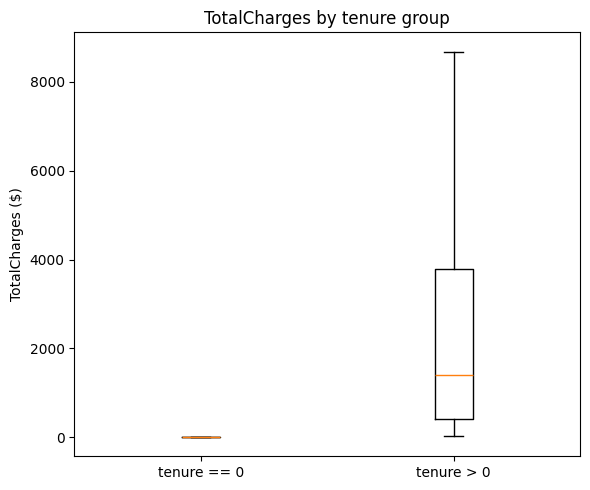

In [55]:
# Split TotalCharges into two groups based on tenure, so we can compare them
zero_tenure_charges = df_clean.loc[df_clean["tenure"] == 0, "TotalCharges"]
other_tenure_charges = df_clean.loc[df_clean["tenure"] > 0, "TotalCharges"]

# Create one figure to draw on
fig, ax = plt.subplots(figsize=(6, 5))

# Draw both groups as boxplots, side by side, for easy comparison
ax.boxplot(
    [zero_tenure_charges, other_tenure_charges],
    tick_labels=["tenure == 0", "tenure > 0"]
)

# Label the axes and give the plot a title, so it's clear on its own
ax.set_ylabel("TotalCharges ($)")
ax.set_title("TotalCharges by tenure group")

plt.tight_layout()  # keeps labels from getting cut off
plt.show()           # actually displays the plot

The `tenure == 0` box sits flat at `0` all 11 values identical. `tenure > 0` shows a normal spread. That flat line confirms the fix: every zero-tenure customer has exactly `0` total charges, not a statistically imputed guess.

## 4. Working-Data EDA

Everything below runs on `df_clean` and reads its column lists from `profile`, built once in Group 2(column profiler). That means the categorical summary, the numeric summary, and the outlier scan are guaranteed to be looking at the same rows and the same column definitions as each other, the inconsistency between `describe()` and the deferred multivariate step in the original notebook (one silently dropping the null row, the other silently imputing it) cannot recur here, because there is only one working frame from this point on.


### Target Column Check and Class Distribution

Confirms the target column is present, then reports the class
distribution as both raw counts and percentages, plus the accuracy a
majority-class guess would achieve. 


In [56]:
def check_class_balance(df: pd.DataFrame, target: str) -> dict:
    """
    Report the target's class distribution (counts and percentages) and
    the majority-class baseline accuracy.
    """
    counts = df[target].value_counts(dropna=False)
    pct = df[target].value_counts(normalize=True, dropna=False) * 100
    majority_pct = pct.max()

    print(counts.to_string())
    print()
    print(pct.round(2).to_string())
    print(f"\nMajority-class baseline accuracy: {majority_pct:.2f}%")

    return {"counts": counts, "pct": pct, "majority_baseline": majority_pct}


class_balance = check_class_balance(df_clean, profile["target"])


Churn
No     5174
Yes    1869

Churn
No     73.46
Yes    26.54

Majority-class baseline accuracy: 73.46%


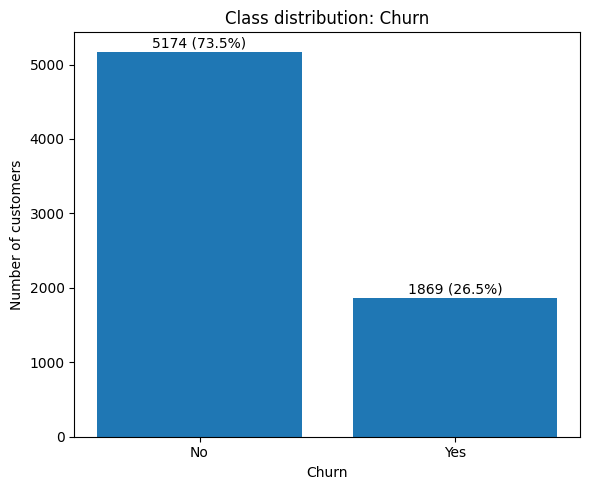

In [60]:
import matplotlib.pyplot as plt

# Count how many customers are in each Churn category
churn_counts = df_clean["Churn"].value_counts()

fig, ax = plt.subplots(figsize=(6, 5))

# Draw one bar per category, using the counts as bar heights
ax.bar(churn_counts.index, churn_counts.values)

# Label each bar with its exact count and percentage, above the bar
total = churn_counts.sum()
for i, count in enumerate(churn_counts.values):
    pct = count / total * 100
    ax.text(i, count + 50, f"{count} ({pct:.1f}%)", ha="center")

ax.set_xlabel("Churn")
ax.set_ylabel("Number of customers")
ax.set_title("Class distribution: Churn")

plt.tight_layout()
plt.show()

**What we found:** No missing values in `Churn`, and exactly the two expected categories — `No` and `Yes`, nothing unexpected slipped in. Class split is 73.5% `No` / 26.5% `Yes` — imbalanced, roughly 3-to-1, though not extreme.

**Effect on cleaning decisions:** Nothing to clean — the target itself is already in good shape. But the imbalance carries forward into how later steps should be read: with a 3-to-1 split, a model that just predicts `No` every time would score 73.5% accuracy while learning nothing, so accuracy alone won't be a meaningful metric once modeling starts. 

### Categorical Columns Summary

For every categorical column in `profile["cat_cols"]`, reports dtype,
unique-value count, and up to 10 observed values — surfaces unexpected
labels or typos before any encoding or cleaning rule is written. Scoped
to `profile` rather than re-selected by dtype, so it can never silently
include an ID or the target the way a fresh `select_dtypes` call could.


In [57]:
def summarize_categorical(df: pd.DataFrame, cat_cols: list) -> pd.DataFrame:
    """
    Per-categorical-column summary: dtype, unique count, sample values.
    """
    rows = []
    for col in cat_cols:
        vals = df[col].dropna().unique()
        rows.append({
            "column": col,
            "dtype": str(df[col].dtype),
            "nunique": df[col].nunique(),
            "sample_values": list(vals[:10]),
        })
    summary = pd.DataFrame(rows)
    print(summary.to_string(index=False))
    return summary


cat_summary = summarize_categorical(df_clean, profile["cat_cols"])


          column dtype  nunique                                                                        sample_values
   MultipleLines   str        3                                                          [No phone service, No, Yes]
 InternetService   str        3                                                               [DSL, Fiber optic, No]
  OnlineSecurity   str        3                                                       [No, Yes, No internet service]
    OnlineBackup   str        3                                                       [Yes, No, No internet service]
DeviceProtection   str        3                                                       [No, Yes, No internet service]
     TechSupport   str        3                                                       [No, Yes, No internet service]
     StreamingTV   str        3                                                       [No, Yes, No internet service]
 StreamingMovies   str        3                                 

**What we found:** 10 categorical columns, each with 3–4 categories. Six of them (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`) share a third category, `"No internet service"`, and `MultipleLines` has the equivalent `"No phone service"` — both flagged earlier in the column descriptions as structurally dependent on `InternetService`/`PhoneService` rather than independent categories. No unexpected values, no typos or case-duplicate categories in any of them — consistent with the earlier mixed-type check finding nothing.

**Effect on cleaning decisions:** No values need fixing. But the "No internet/phone service" category is worth carrying forward as a flag for encoding, not cleaning.

### Numeric Columns Summary

Runs `describe()` on `profile["num_cols"]` only — the identifier and the
target are excluded by construction, so no meaningless mean-of-an-ID or
mean-of-a-binary-target rows can appear here the way `CustomerID` did in
the original pass. Minimums and maximums that fall outside a plausible
domain range would be visible directly from this table.


In [58]:
def summarize_numeric(df: pd.DataFrame, num_cols: list) -> pd.DataFrame:
    """
    describe() restricted to the modelling-relevant numeric columns.
    """
    summary = df[num_cols].describe().T
    print(summary)
    return summary


num_summary = summarize_numeric(df_clean, profile["num_cols"])


                 count         mean          std    min     25%      50%      75%      max
tenure          7043.0    32.371149    24.559481   0.00    9.00    29.00    55.00    72.00
MonthlyCharges  7043.0    64.761692    30.090047  18.25   35.50    70.35    89.85   118.75
TotalCharges    7043.0  2279.734304  2266.794470   0.00  398.55  1394.55  3786.60  8684.80


**What we found:** `tenure` ranges 0–72 months, median 29 — a wide spread, no obvious outliers. `MonthlyCharges` ranges $18.25–$118.75, fairly evenly spread (mean and median close: 64.76 vs 70.35). `TotalCharges` ranges $0–$8,684.80 with a large std relative to its mean  expected, since it's a running total over `tenure`, so it inherits and compounds tenure's  spread. The `TotalCharges` minimum of exactly `0` is the 11 rows filled in Group 3, not a new finding.

**Effect on cleaning decisions:** No outlier treatment needed every range is consistent with what the column is supposed to represent, no values outside physically plausible bounds.

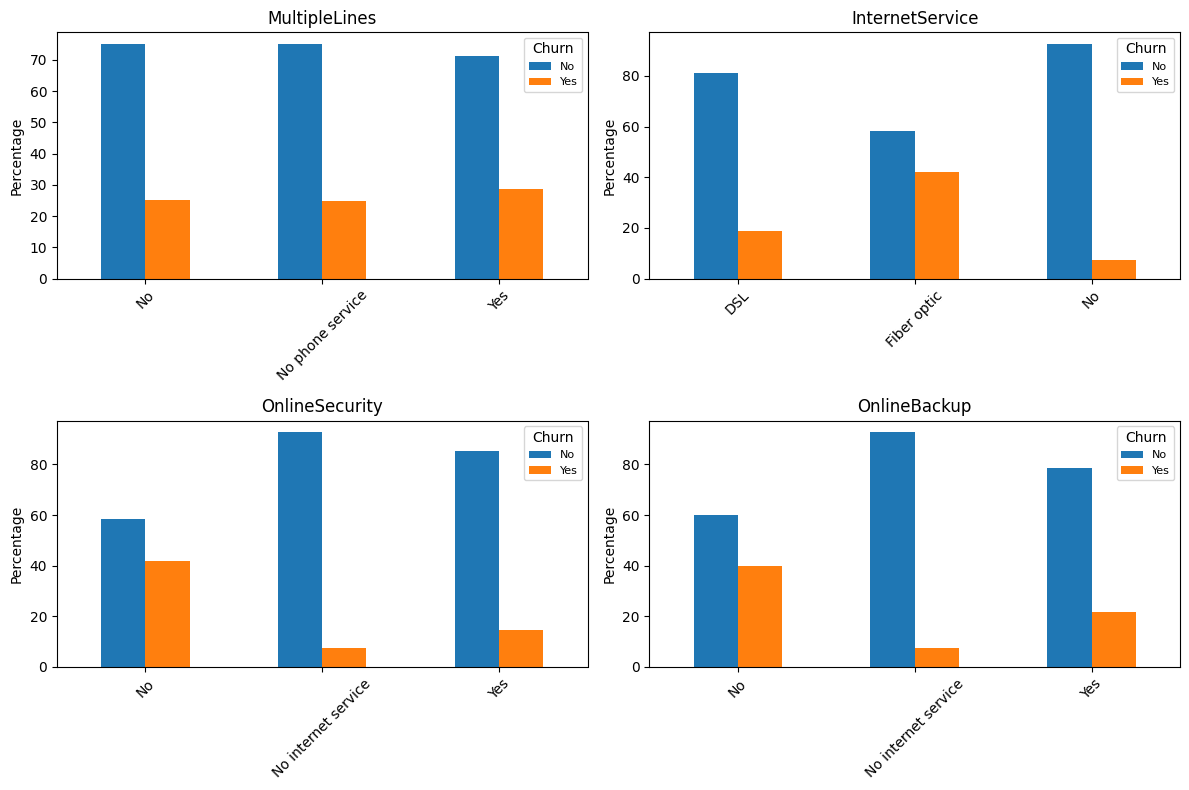

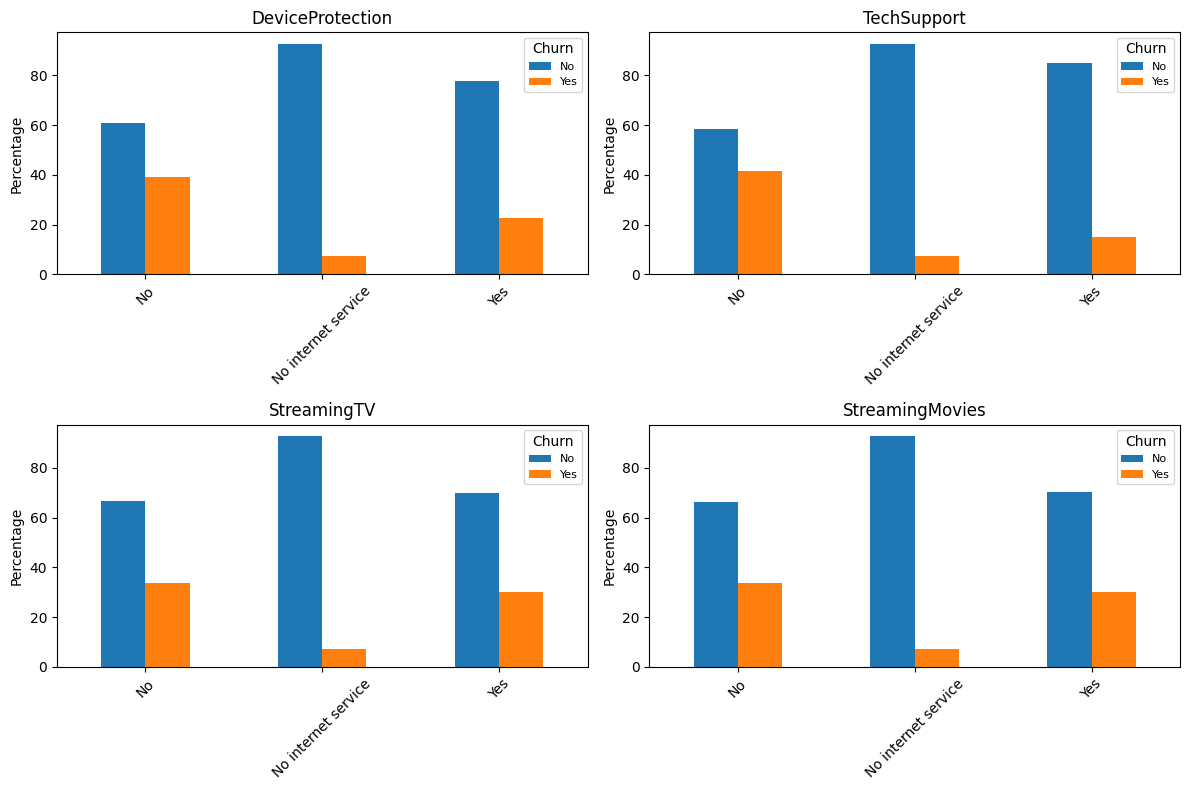

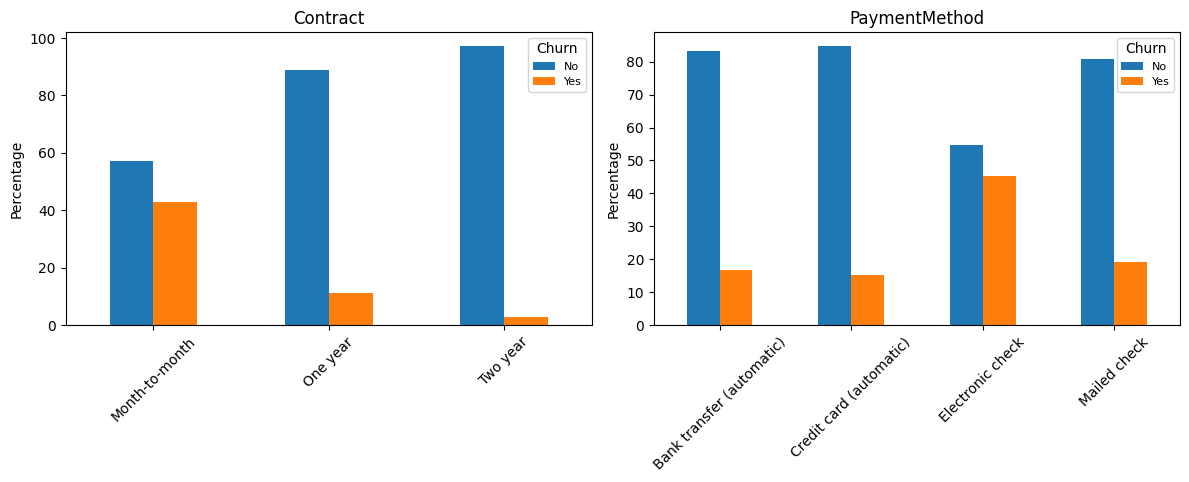

In [66]:
def plot_churn_rate_grid(df: pd.DataFrame, cols: list, target: str = "Churn", cols_per_row: int = 2):
    """
    Draw churn-rate-by-category bar charts for a list of columns, four
    to a figure, arranged in a 2x2 grid, so many columns can be scanned
    a few at a time instead of one full-width plot per column.
    """
    n = len(cols)
    rows_per_fig = 2  # 2 rows x 2 cols = 4 plots per figure

    fig, axes = plt.subplots(rows_per_fig, cols_per_row, figsize=(12, 8))
    axes = axes.flatten()  # turn the 2x2 grid of axes into a flat list of 4

    for i, col in enumerate(cols):
        rates = pd.crosstab(df[col], df[target], normalize="index") * 100
        rates.plot(kind="bar", ax=axes[i])
        axes[i].set_title(col)
        axes[i].set_xlabel("")
        axes[i].set_ylabel("Percentage")
        axes[i].tick_params(axis="x", rotation=45)
        axes[i].legend(title="Churn", fontsize=8)

    # if fewer than 4 columns are left in the last batch, hide the
    # empty subplot slots instead of leaving them blank and confusing
    for j in range(len(cols), rows_per_fig * cols_per_row):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()


all_cols = profile["cat_cols"]
chunk_size = 4

for start in range(0, len(all_cols), chunk_size):
    batch = all_cols[start:start + chunk_size]
    plot_churn_rate_grid(df_clean, batch)

A column where every category shows roughly the same churn split is a weak candidate; one where a category stands out sharply is a strong one. 

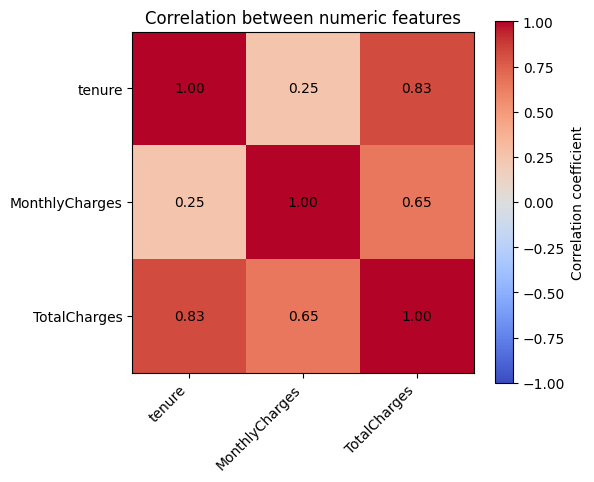

In [63]:
import matplotlib.pyplot as plt
import numpy as np

# Compute the correlation matrix for the numeric columns only
corr_matrix = df_clean[profile["num_cols"]].corr()

fig, ax = plt.subplots(figsize=(6, 5))

# Draw the matrix as a grid of colored cells
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)

# Label each row and column with its column name
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(corr_matrix.columns)

# Write the actual correlation value inside each cell
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        value = corr_matrix.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", color="black")

ax.set_title("Correlation between numeric features")
fig.colorbar(im, ax=ax, label="Correlation coefficient")

plt.tight_layout()
plt.show()

`tenure` and `TotalCharges` are strongly correlated, and `MonthlyCharges`/`TotalCharges` moderately so confirming the structural relationship already found in Group 3: `TotalCharges` accumulates from `tenure` and `MonthlyCharges`, so it's carryingoverlapping information, not fully independent signal.

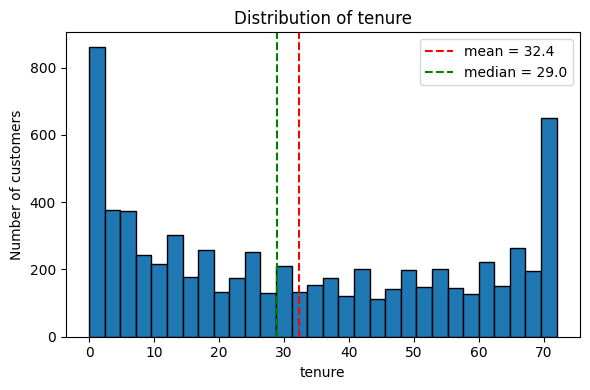

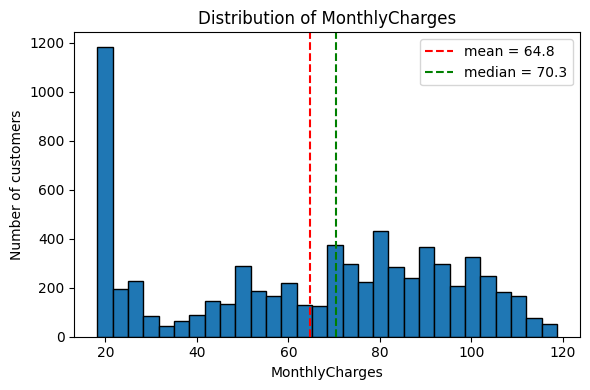

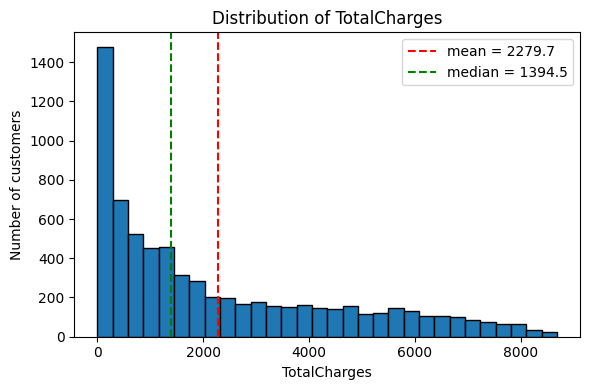

In [68]:
import matplotlib.pyplot as plt

def plot_distribution(df: pd.DataFrame, num_col: str, bins: int = 30):
    """
    Plain histogram of one numeric column - shows its overall shape
    (skew, spread, any obvious gaps or spikes) before splitting by the
    target. This is what backs up a claim like "TotalCharges is
    right-skewed" with an actual picture, not just the describe() stats.
    """
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(df[num_col].dropna(), bins=bins, edgecolor="black")

    # mark the mean and median so skew is visible, not just implied by shape
    mean_val = df[num_col].mean()
    median_val = df[num_col].median()
    ax.axvline(mean_val, color="red", linestyle="--", label=f"mean = {mean_val:.1f}")
    ax.axvline(median_val, color="green", linestyle="--", label=f"median = {median_val:.1f}")

    ax.set_xlabel(num_col)
    ax.set_ylabel("Number of customers")
    ax.set_title(f"Distribution of {num_col}")
    ax.legend()

    plt.tight_layout()
    plt.show()


for col in profile["num_cols"]:
    plot_distribution(df_clean, col)

### Boolean Column Summary

Same purpose as the categorical summary above, run separately because `profile["bool_cols"]` holds a different set of columns which are the ones
classified as two-valued rather than low-cardinality-but-more-than-two. Checked for category count, actual values, and any missing entries.
`date_cols` and `text_cols` are both empty in this dataset's profile there's no datetime column and no free-text field — so there's nothing to summarize for either, and no cell is needed for them.

In [59]:
def summarize_boolean(df: pd.DataFrame, bool_cols: list) -> pd.DataFrame:
    """
    For each boolean-role column: dtype, number of distinct values, the
    values themselves, and how many are missing.
    """
    rows = []
    for col in bool_cols:
        rows.append({
            "column": col,
            "dtype": str(df[col].dtype),
            "nunique": df[col].nunique(),
            "values": sorted(df[col].dropna().unique().tolist(), key=str),
            "n_missing": int(df[col].isna().sum()),
        })
    return pd.DataFrame(rows)


boolean_summary = summarize_boolean(df_clean, profile["bool_cols"])
boolean_summary

,column,dtype,nunique,values,n_missing
0,gender,str,2,"[Female, Male]",0
1,SeniorCitizen,int64,2,"[0, 1]",0
2,Partner,str,2,"[No, Yes]",0
3,Dependents,str,2,"[No, Yes]",0
4,PhoneService,str,2,"[No, Yes]",0
5,PaperlessBilling,str,2,"[No, Yes]",0


**What we found:** [fill in once run expect `SeniorCitizen` (0/1), `Partner`, `Dependents`, `PhoneService`, `PaperlessBilling`, and `gender` under the general two-value rule, each with exactly 2 values and no missing entries.]

**Effect on cleaning decisions:** No values need fixing every boolean-role column already has exactly two clean, consistent values. Worth noting for later, not now: these columns are ready for binary encoding (0/1) as-is, with no intermediate cleaning step required between this point and modeling.

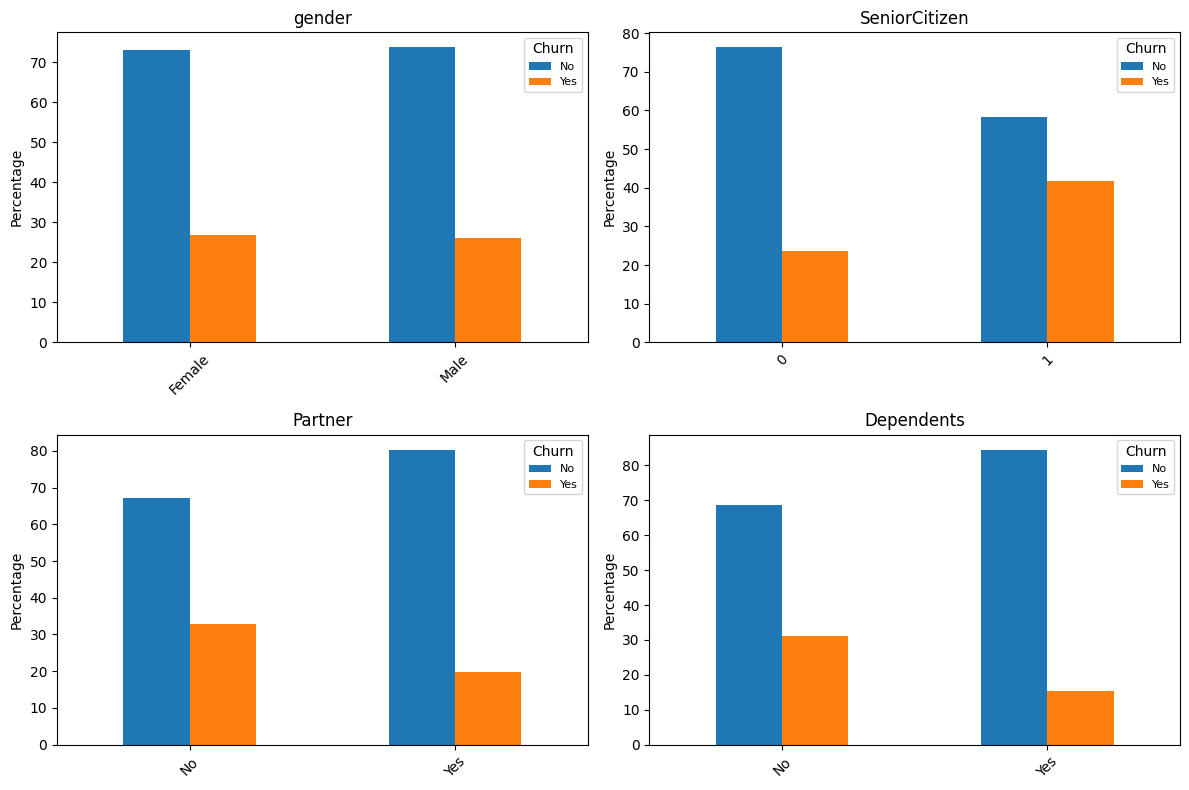

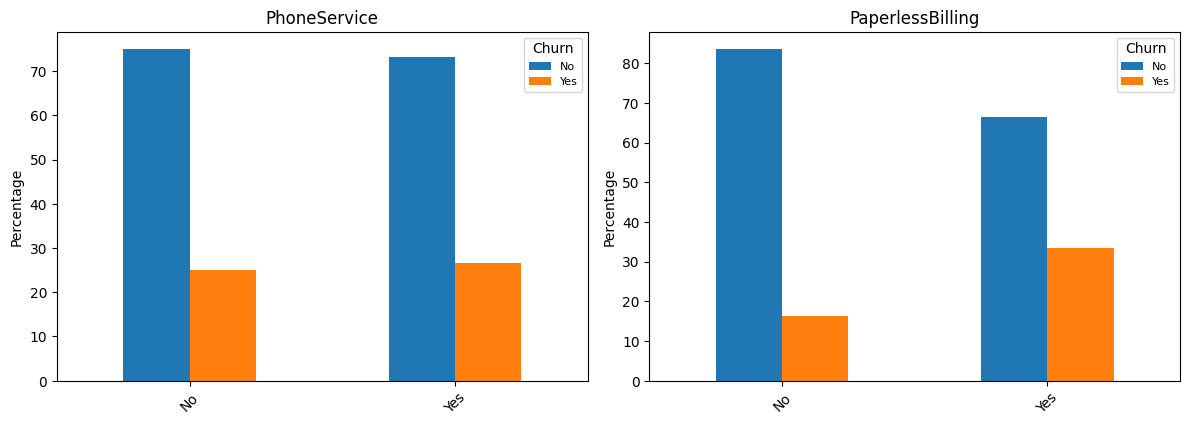

In [67]:
all_cols = profile["bool_cols"]
chunk_size = 4

for start in range(0, len(all_cols), chunk_size):
    batch = all_cols[start:start + chunk_size]
    plot_churn_rate_grid(df_clean, batch)

With only two categories each, the comparison here is simpler than for `cat_cols` (one bar pair per column instead of three or four), but the same rule applies a near-identical split between both values is weak evidence, a clearly different split is strong evidence. 